<a href="https://colab.research.google.com/github/Arnavpanwar1312/Arnav_Panwar/blob/main/EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Load Required Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/indo_rct.csv"
data= pd.read_csv(url)

Step 2: Load Dataset

In [12]:
# Display first records
print("First 5 Rows:")
print(data.head())

# Display last records
print("\nLast 5 Rows:")
print(data.tail())

# Display dimensions
print("\nDimensions:")
print(data.shape)

# Display structure
print("\nData Types:")
print(data.info())

# Display column names
print("\nColumn Names:")
print(data.columns)

First 5 Rows:
   rownames    id  site  age  risk    gender outcome    sod    pep recpanc  \
0         1  1001  1_UM   26   2.0  1_female   1_yes  1_yes   0_no   1_yes   
1         2  1002  1_UM   24   1.0    2_male    0_no   0_no  1_yes    0_no   
2         3  1003  1_UM   57   1.0  1_female    0_no  1_yes   0_no    0_no   
3         4  1004  1_UM   29   2.0  1_female   1_yes  1_yes   0_no    0_no   
4         5  1005  1_UM   38   3.5  1_female    0_no  1_yes  1_yes    0_no   

   ... sodsom bsphinc bstent  chole pbmal  train        status      type  \
0  ...   0_no    0_no   0_no   0_no  0_no  1_yes  1_outpatient  1_type 1   
1  ...   0_no   1_yes  1_yes  1_yes  0_no   0_no  1_outpatient  0_no SOD   
2  ...   0_no    0_no   0_no   0_no  0_no   0_no  1_outpatient  2_type 2   
3  ...   0_no   1_yes   0_no  1_yes  0_no  1_yes  1_outpatient  1_type 1   
4  ...  1_yes   1_yes   0_no   0_no  0_no  1_yes   0_inpatient  1_type 1   

               rx bleed  
0  1_indomethacin   NaN  
1       

  Step 3: Basic Statistical Analysis

In [13]:
# Summary Statistics
print("\nSummary Statistics:")
print(data.describe(include='all'))

# Mean
print("\nMean:")
print(data.mean(numeric_only=True))

# Median
print("\nMedian:")
print(data.median(numeric_only=True))

# Standard Deviation
print("\nStandard Deviation:")
print(data.std(numeric_only=True))

# Variance
print("\nVariance:")
print(data.var(numeric_only=True))

# Correlation Matrix
num_data = data.select_dtypes(include=np.number)

print("\nCorrelation Matrix:")
print(num_data.corr())


Summary Statistics:
          rownames           id  site         age        risk    gender  \
count   602.000000   602.000000   602  602.000000  602.000000       602   
unique         NaN          NaN     4         NaN         NaN         2   
top            NaN          NaN  2_IU         NaN         NaN  1_female   
freq           NaN          NaN   413         NaN         NaN       476   
mean    301.500000  1939.425249   NaN   45.269103    2.381229       NaN   
std     173.926709   568.733133   NaN   13.297968    0.881269       NaN   
min       1.000000  1001.000000   NaN   19.000000    1.000000       NaN   
25%     151.250000  1152.250000   NaN   35.000000    1.500000       NaN   
50%     301.500000  2137.500000   NaN   45.000000    2.500000       NaN   
75%     451.750000  2288.750000   NaN   54.000000    3.000000       NaN   
max     602.000000  4003.000000   NaN   90.000000    5.500000       NaN   

       outcome    sod   pep recpanc  ... sodsom bsphinc bstent chole pbmal  \


Step 4: Handle Missing Values

In [14]:
# Check Missing Values
print("\nMissing Values:")
print(data.isnull().sum())

# Percentage of Missing Values
print("\nPercentage of Missing Values:")
print(data.isnull().mean() * 100)

# Replace Missing Values with Mean
for col in num_data.columns:
    data[col] = data[col].fillna(data[col].mean())

# Verify Missing Values
print("\nMissing Values After Replacement:")
print(data.isnull().sum())



Missing Values:
rownames         0
id               0
site             0
age              0
risk             0
gender           0
outcome          0
sod              0
pep              0
recpanc          0
psphinc          0
precut           0
difcan           0
pneudil          0
amp              0
paninj           0
acinar           0
brush            0
asa81            0
asa325           0
asa              0
prophystent      0
therastent       0
pdstent          0
sodsom           0
bsphinc          0
bstent           0
chole            0
pbmal            0
train            0
status           0
type             0
rx               0
bleed          575
dtype: int64

Percentage of Missing Values:
rownames        0.00000
id              0.00000
site            0.00000
age             0.00000
risk            0.00000
gender          0.00000
outcome         0.00000
sod             0.00000
pep             0.00000
recpanc         0.00000
psphinc         0.00000
precut          0.00000
difca

Step 5: Data Cleaning

In [15]:
# Remove Duplicate Rows
data = data.drop_duplicates()

# Check Duplicate Rows
print("\nDuplicate Rows:", data.duplicated().sum())

# Check Data Types
print("\nData Types:")
print(data.dtypes)


Duplicate Rows: 0

Data Types:
rownames         int64
id               int64
site            object
age              int64
risk           float64
gender          object
outcome         object
sod             object
pep             object
recpanc         object
psphinc         object
precut          object
difcan          object
pneudil         object
amp             object
paninj          object
acinar          object
brush           object
asa81           object
asa325          object
asa             object
prophystent     object
therastent      object
pdstent         object
sodsom          object
bsphinc         object
bstent          object
chole           object
pbmal           object
train           object
status          object
type            object
rx              object
bleed          float64
dtype: object


 Step 6: Data Transformation

In [16]:
# Normalize Numeric Columns (Min-Max Scaling)
data_norm = data.copy()

for col in num_data.columns:
    data_norm[col] = (
        (data[col] - data[col].min()) /
        (data[col].max() - data[col].min())
    )

print("\nNormalized Data:")
print(data_norm.head())


Normalized Data:
   rownames        id  site       age      risk    gender outcome    sod  \
0  0.000000  0.000000  1_UM  0.098592  0.222222  1_female   1_yes  1_yes   
1  0.001664  0.000333  1_UM  0.070423  0.000000    2_male    0_no   0_no   
2  0.003328  0.000666  1_UM  0.535211  0.000000  1_female    0_no  1_yes   
3  0.004992  0.000999  1_UM  0.140845  0.222222  1_female   1_yes  1_yes   
4  0.006656  0.001332  1_UM  0.267606  0.555556  1_female    0_no  1_yes   

     pep recpanc  ... sodsom bsphinc bstent  chole pbmal  train        status  \
0   0_no   1_yes  ...   0_no    0_no   0_no   0_no  0_no  1_yes  1_outpatient   
1  1_yes    0_no  ...   0_no   1_yes  1_yes  1_yes  0_no   0_no  1_outpatient   
2   0_no    0_no  ...   0_no    0_no   0_no   0_no  0_no   0_no  1_outpatient   
3   0_no    0_no  ...   0_no   1_yes   0_no  1_yes  0_no  1_yes  1_outpatient   
4  1_yes    0_no  ...  1_yes   1_yes   0_no   0_no  0_no  1_yes   0_inpatient   

       type              rx     bleed 

Step 7: Univariate Analysis

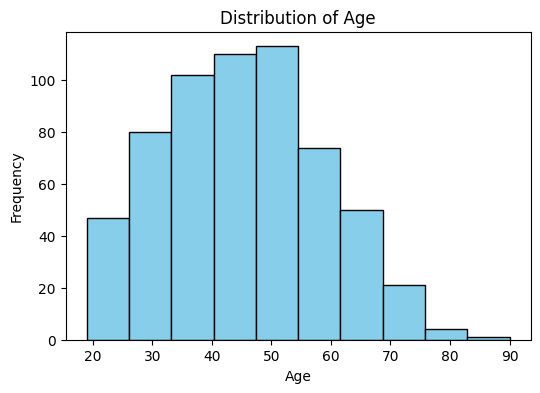

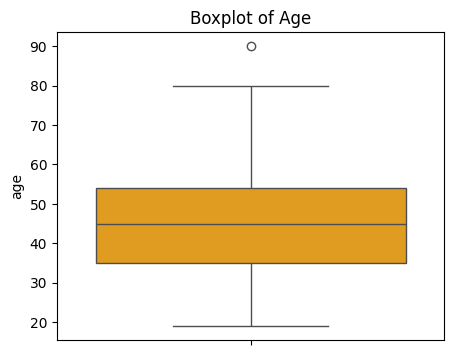

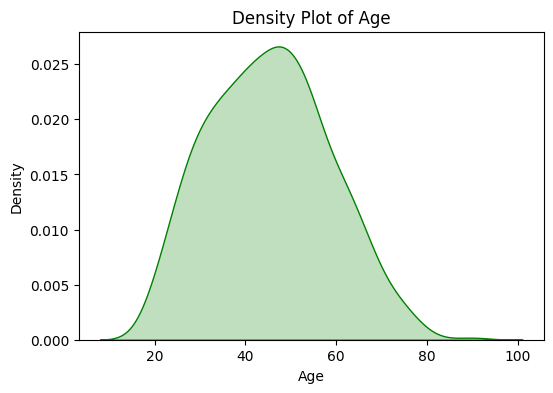

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(6,4))
plt.hist(data["age"], bins=10, color="skyblue", edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Box Plot
plt.figure(figsize=(5,4))
sns.boxplot(y=data["age"], color="orange")
plt.title("Boxplot of Age")
plt.show()

# Density Plot
plt.figure(figsize=(6,4))
sns.kdeplot(data["age"], fill=True, color="green")
plt.title("Density Plot of Age")
plt.xlabel("Age")
plt.show()

 Step 8: Bivariate Analysis

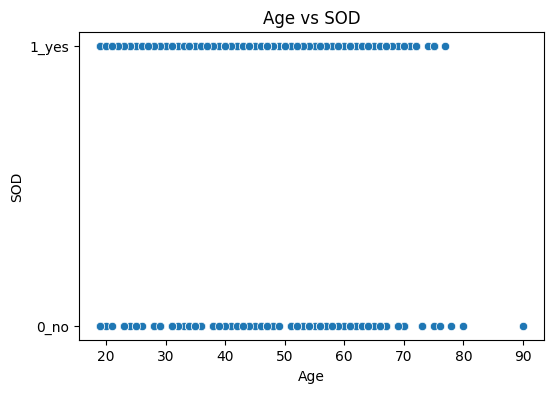

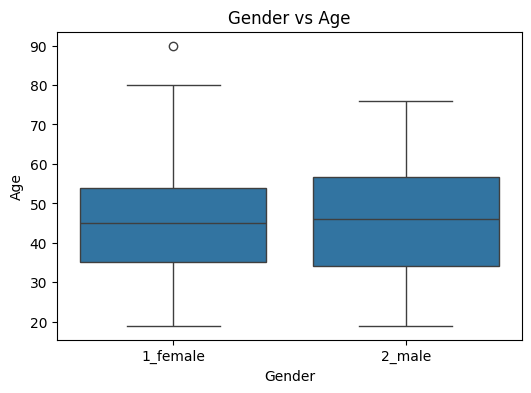

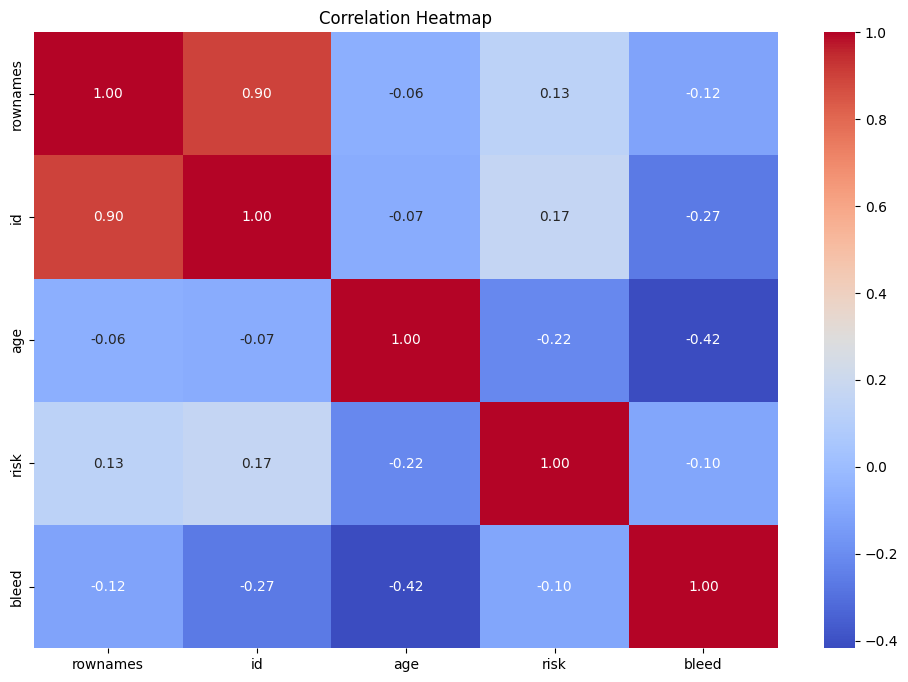

In [18]:
# Scatter Plot (Age vs SOD)
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="sod", data=data)
plt.title("Age vs SOD")
plt.xlabel("Age")
plt.ylabel("SOD")
plt.show()

# Box Plot (Gender vs Age)
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="age", data=data)
plt.title("Gender vs Age")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(num_data.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Step 9: Multivariate Analysis

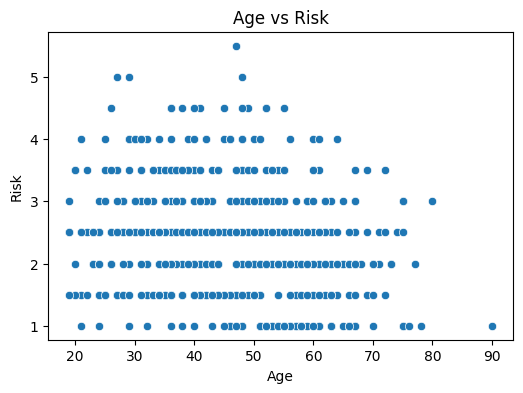

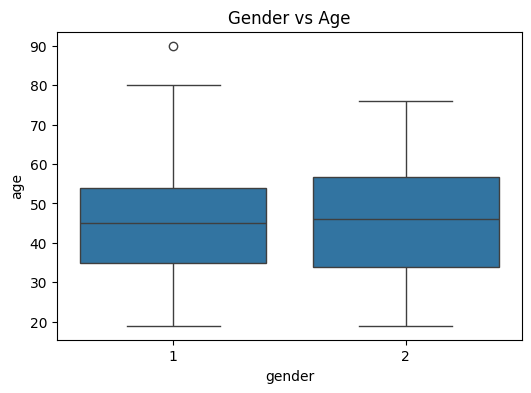

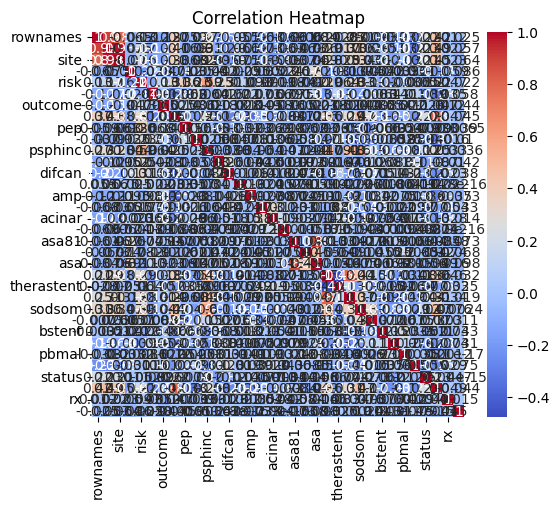

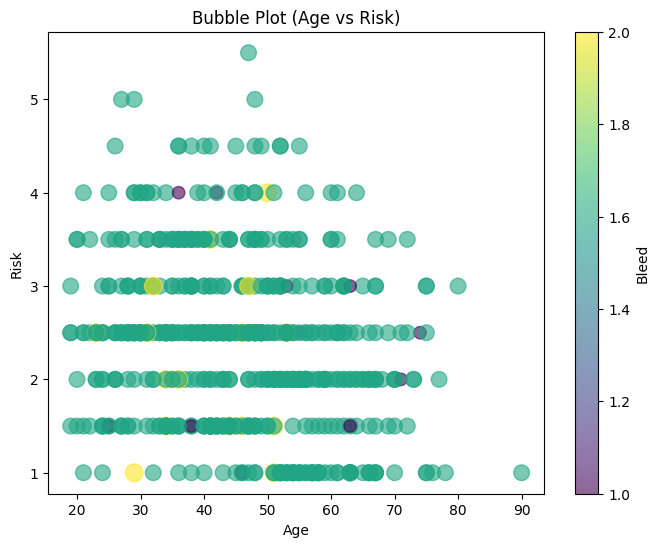

In [19]:
# Convert all 0_no / 1_yes columns into 0 and 1
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].astype(str).str.extract(r'(^\d)').fillna(0).astype(int)

#Scatter Plot (Age vs Risk)
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="risk", data=data)
plt.title("Age vs Risk")
plt.xlabel("Age")
plt.ylabel("Risk")
plt.show()
#Box Plot (Gender vs Age)
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="age", data=data)
plt.title("Gender vs Age")
plt.show()
#Correlation Heatmap
num_data = data.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(6,5))
sns.heatmap(num_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
#Pair Plot
sns.pairplot(num_data)
plt.show()
#Bubble Plot (Age vs Risk)
plt.figure(figsize=(8,6))
plt.scatter(
    data["age"],
    data["risk"],
    s=data["bleed"]*80,
    c=data["bleed"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Risk")
plt.title("Bubble Plot (Age vs Risk)")
plt.colorbar(label="Bleed")
plt.show()


PHASE 2: STATISTICAL ANALYSIS & CLUSTERING

In [20]:
import scipy.stats as stats
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

9. 1D Statistical Analysis

--- 1D Summary Statistics ---


,Mean,Median,Min,Max,Range,Variance,Std_Dev,IQR,Skewness,Kurtosis
age,45.269103,45.0,19,90,71,176.835949,13.297968,19.0,0.201422,-0.517199
sod,0.822259,1.0,0,1,1,0.146392,0.382612,0.0,-1.685921,0.842330
pep,0.159468,0.0,0,1,1,0.134261,0.366417,0.0,1.860257,1.460557



--- Outcome Frequency Table ---
outcome
0    523
1     79
Name: count, dtype: int64

--- Relative Frequency (%) ---
outcome
0    86.877076
1    13.122924
Name: proportion, dtype: float64


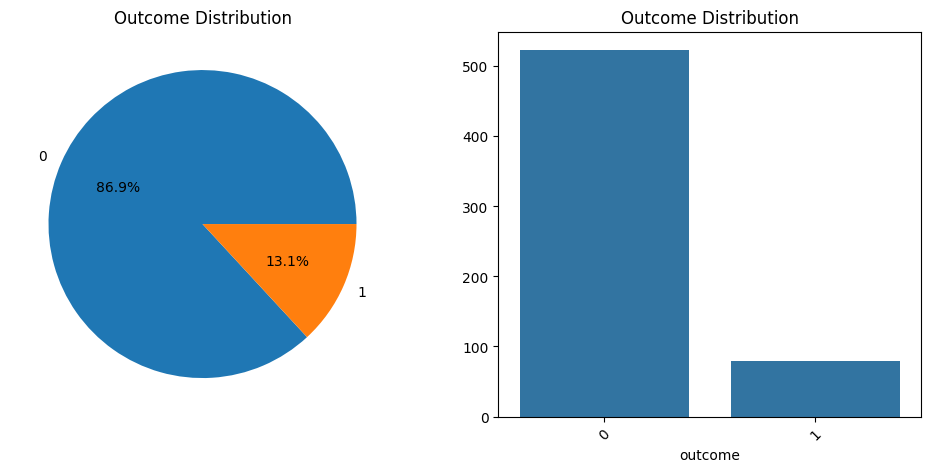


--- Age Binned Frequency Table ---
age_bins
(18.929, 33.2]    127
(33.2, 47.4]      212
(47.4, 61.6]      187
(61.6, 75.8]       71
(75.8, 90.0]        5
Name: count, dtype: int64


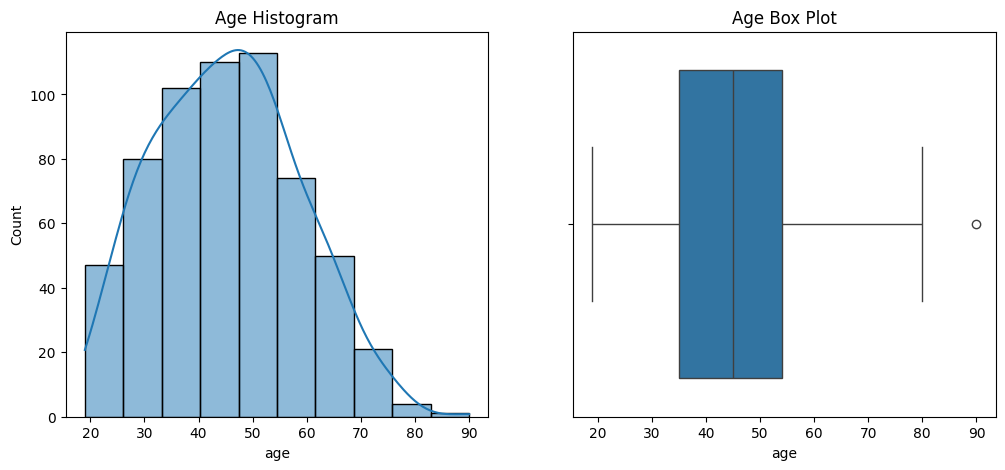

In [21]:
# Numerical columns that I will use for the analysis
numeric_cols = ['age', 'sod', 'pep']

# Summary statistics
stats_data= pd.DataFrame({
    'Mean': data[numeric_cols].mean(),
    'Median': data[numeric_cols].median(),
    'Min': data[numeric_cols].min(),
    'Max': data[numeric_cols].max(),
    'Range': data[numeric_cols].max() - data[numeric_cols].min(),
    'Variance': data[numeric_cols].var(),
    'Std_Dev': data[numeric_cols].std(),
    'IQR': data[numeric_cols].apply(stats.iqr),
    'Skewness': data[numeric_cols].apply(
        stats.skew, nan_policy='omit'
    ),
    'Kurtosis': data[numeric_cols].apply(
        stats.kurtosis, nan_policy='omit'
    )
})

print("--- 1D Summary Statistics ---")
display(stats_data)


# Frequency of each outcome
freq_table = data['outcome'].value_counts()

rel_freq_table = (
    data['outcome'].value_counts(normalize=True) * 100
)

print("\n--- Outcome Frequency Table ---")
print(freq_table)

print("\n--- Relative Frequency (%) ---")
print(rel_freq_table)


# Pie chart and bar chart for outcome
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    freq_table,
    labels=freq_table.index,
    autopct='%1.1f%%'
)

axes[0].set_title('Outcome Distribution')


sns.barplot(
    x=freq_table.index,
    y=freq_table.values,
    ax=axes[1]
)

axes[1].set_title('Outcome Distribution')

plt.xticks(rotation=45)
plt.show()


# Creating age groups for a frequency table
data['age_bins'] = pd.cut(data['age'], bins=5)

print("\n--- Age Binned Frequency Table ---")
print(
    data['age_bins']
    .value_counts()
    .sort_index()
)


# Histogram and boxplot for age
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data['age'],
    bins=10,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Age Histogram')

sns.boxplot(
    x=data['age'],
    ax=axes[1]
)

axes[1].set_title('Age Box Plot')

plt.show()

10. 2D Statistical Analysis


--- Contingency Table ---
outcome    0   1  All
risk                 
1.0       60   6   66
1.5       83   6   89
2.0       91  13  104
2.5      154  17  171
3.0       52  18   70
3.5       49  11   60
4.0       22   4   26
4.5       10   2   12
5.0        2   1    3
5.5        0   1    1
All      523  79  602

--- Row Percentages ---
outcome          0           1
risk                          
1.0      90.909091    9.090909
1.5      93.258427    6.741573
2.0      87.500000   12.500000
2.5      90.058480    9.941520
3.0      74.285714   25.714286
3.5      81.666667   18.333333
4.0      84.615385   15.384615
4.5      83.333333   16.666667
5.0      66.666667   33.333333
5.5       0.000000  100.000000


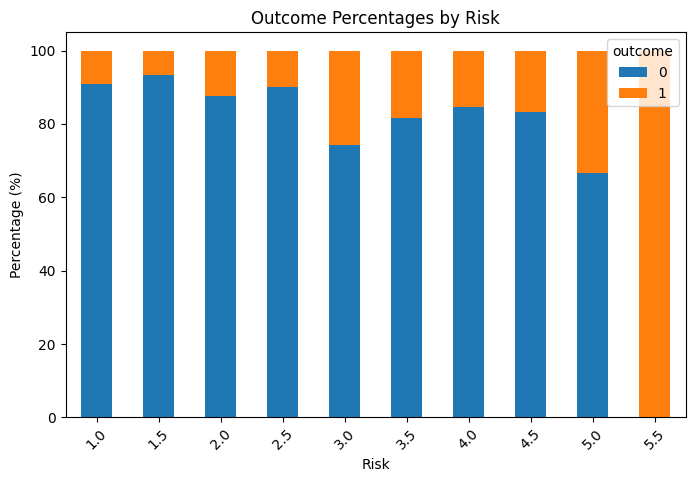


--- Age Stats Grouped by Outcome ---


,mean,median,std
outcome,,,
0,45.512428,46.0,13.369109
1,43.658228,43.0,12.782085


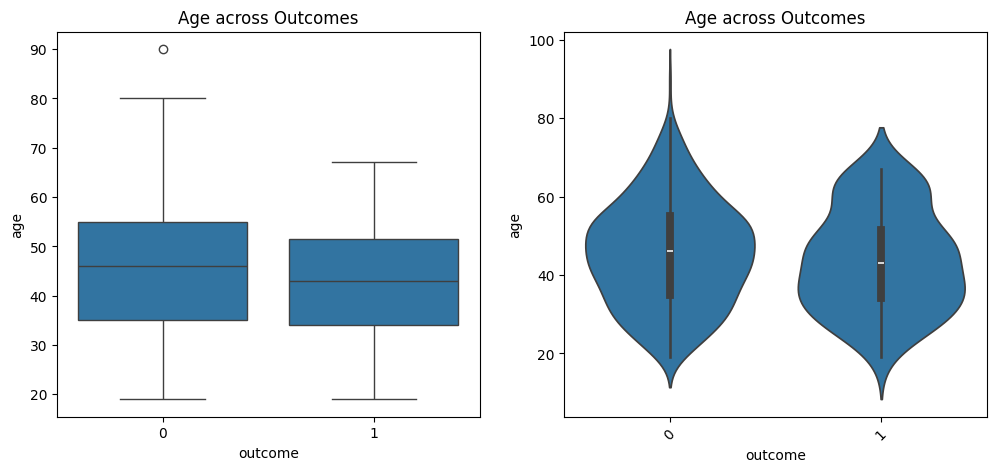


Pearson Correlation (Age & SOD): -0.138
Spearman Correlation (Age & SOD): -0.124


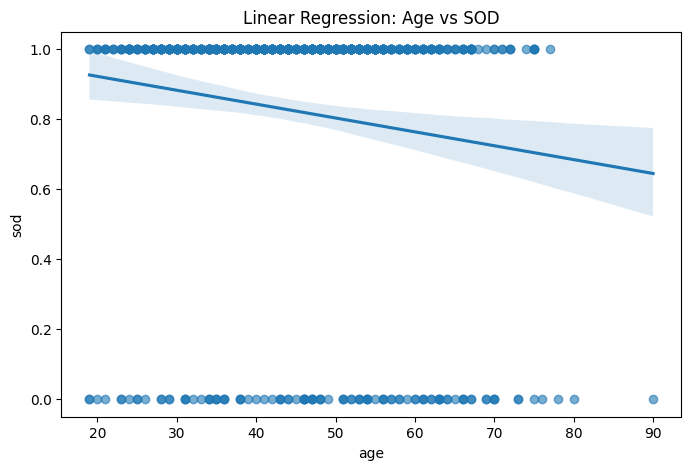

In [22]:
# Contingency table for risk and outcome
cross_tab = pd.crosstab(
    data['risk'],
    data['outcome'],
    margins=True
)

row_perc = pd.crosstab(
    data['risk'],
    data['outcome'],
    normalize='index'
) * 100

print("\n--- Contingency Table ---")
print(cross_tab)

print("\n--- Row Percentages ---")
print(row_perc)


# Stacked bar chart
row_perc.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Outcome Percentages by Risk')
plt.ylabel('Percentage (%)')
plt.xlabel('Risk')

plt.xticks(rotation=45)
plt.show()


# Age statistics for each outcome
grouped_stats = data.groupby(
    'outcome'
)['age'].agg([
    'mean',
    'median',
    'std'
])

print("\n--- Age Stats Grouped by Outcome ---")
display(grouped_stats)


# Boxplot and violin plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=data,
    x='outcome',
    y='age',
    ax=axes[0]
)

axes[0].set_title('Age across Outcomes')

sns.violinplot(
    data=data,
    x='outcome',
    y='age',
    ax=axes[1]
)

axes[1].set_title('Age across Outcomes')

plt.xticks(rotation=45)
plt.show()


# Pearson and Spearman correlation
pearson_corr = data['age'].corr(
    data['sod'],
    method='pearson'
)

spearman_corr = data['age'].corr(
    data['sod'],
    method='spearman'
)

print(
    f"\nPearson Correlation (Age & SOD): "
    f"{pearson_corr:.3f}"
)

print(
    f"Spearman Correlation (Age & SOD): "
    f"{spearman_corr:.3f}"
)


# Regression plot
plt.figure(figsize=(8, 5))

sns.regplot(
    data=data,
    x='age',
    y='sod',
    scatter_kws={'alpha': 0.6}
)

plt.title('Linear Regression: Age vs SOD')
plt.show()

11. 3D Statistical Analysis

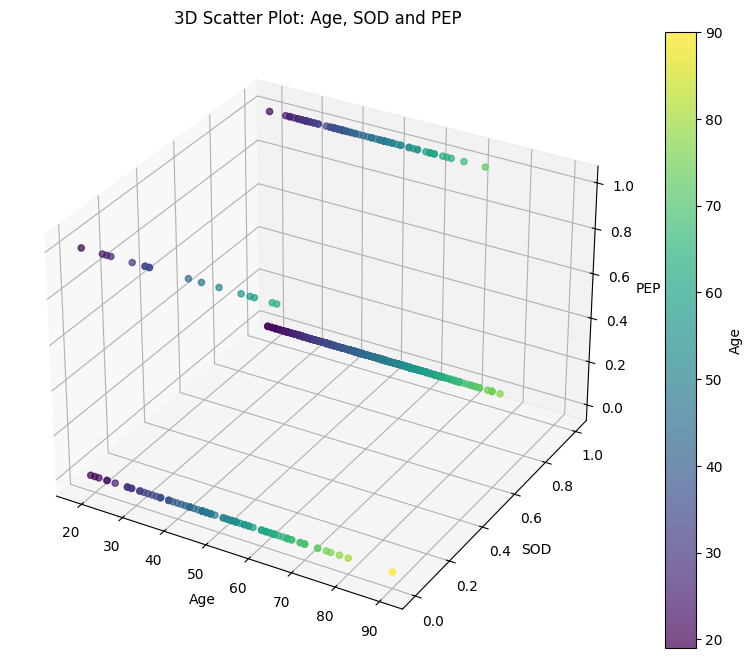

In [23]:
from mpl_toolkits.mplot3d import Axes3D

# Using three numerical variables for the 3D plot
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

x = data['age']
y = data['sod']
z = data['pep']


# 3D scatter plot
scatter = ax.scatter(
    x,
    y,
    z,
    c=data['age'],
    cmap='viridis',
    marker='o',
    alpha=0.7
)

ax.set_xlabel('Age')
ax.set_ylabel('SOD')
ax.set_zlabel('PEP')

plt.title('3D Scatter Plot: Age, SOD and PEP')

fig.colorbar(
    scatter,
    ax=ax,
    label='Age'
)

plt.show()

12. ND / Multivariate Analysis


--- Age Stats across Risk and Outcome ---


mean        std
risk outcome                      
1.0  0        55.366667  12.507580
     1        56.500000   8.596511
1.5  0        42.457831  12.257702
     1        38.833333  16.570053
2.0  0        50.692308  13.246125
     1        51.000000  13.874437
2.5  0        41.876623  12.312026
     1        41.176471  10.619765
3.0  0        46.192308  14.186487
     1        42.722222  11.959764
3.5  0        42.000000  11.476425
     1        40.454545  12.848063
4.0  0        41.772727  12.078836
     1        36.750000   9.287088
4.5  0        44.100000   9.011721
     1        38.500000   3.535534
5.0  0        37.500000  14.849242
     1        29.000000        NaN
5.5  1        47.000000        NaN

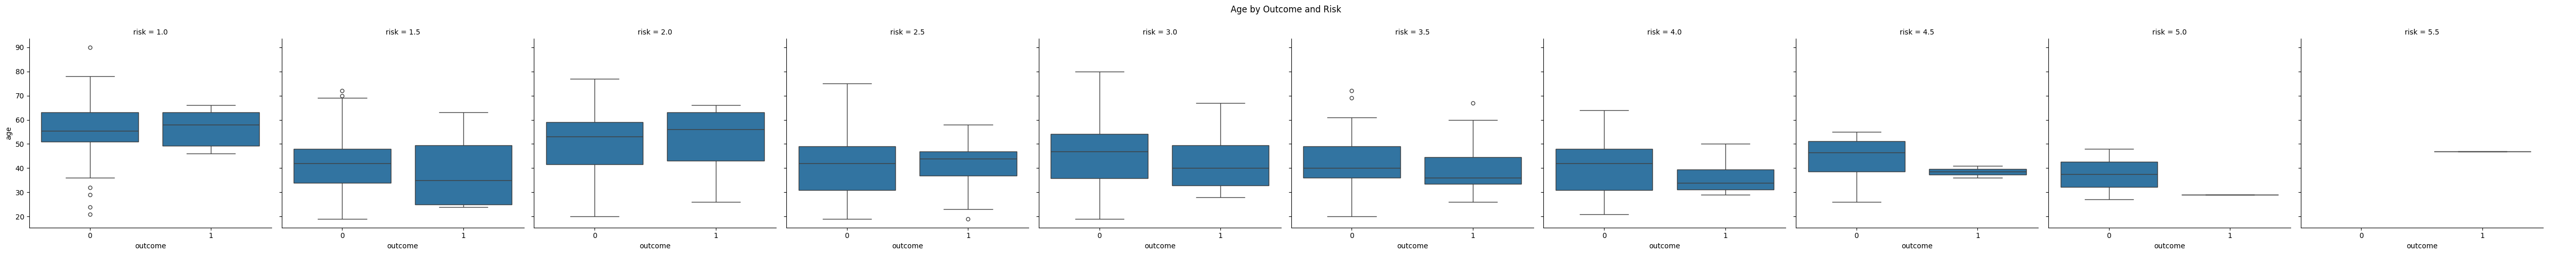

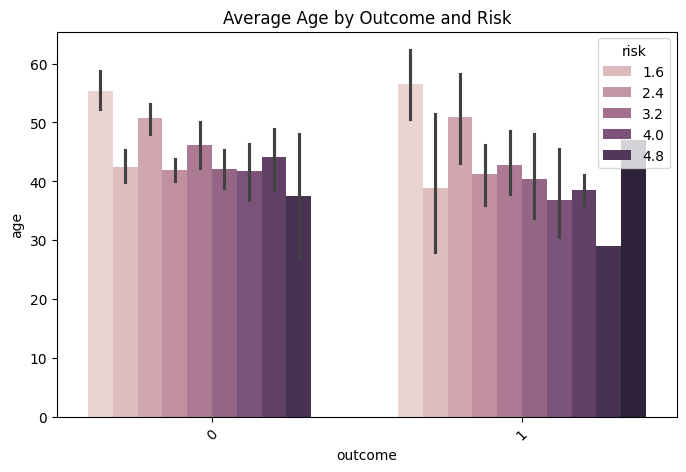


--- Correlation (Age vs SOD) for Each Outcome ---
Outcome '1': -0.162
Outcome '0': -0.136


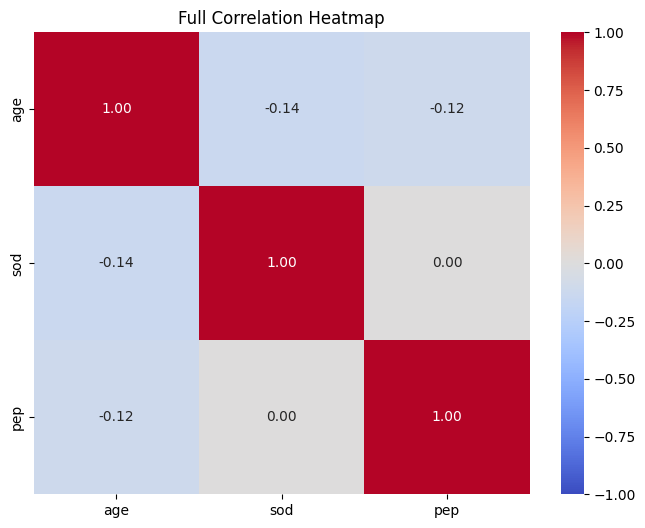

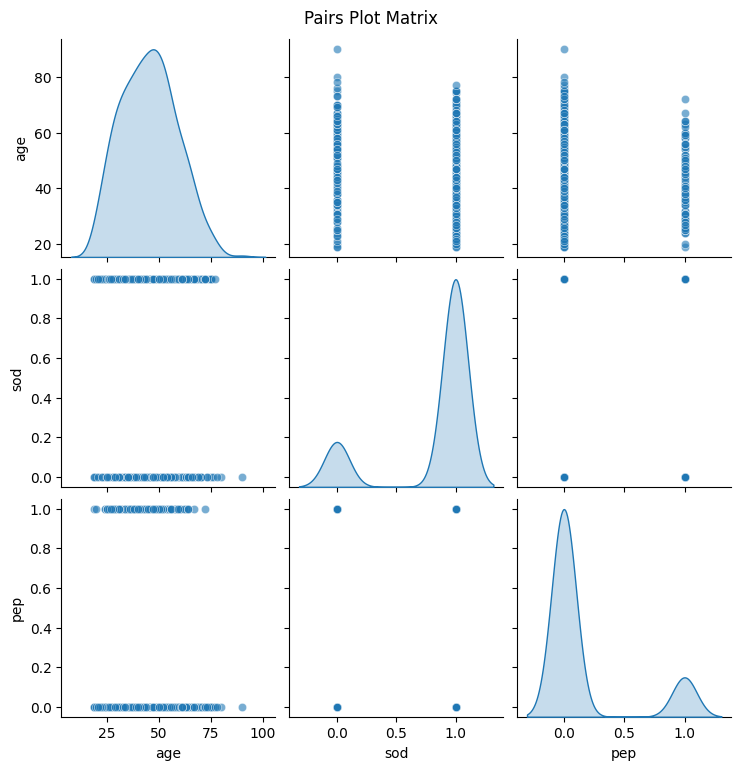

In [24]:
# Comparing age for different combinations of risk and outcome
multi_group_stats = data.groupby(
    ['risk', 'outcome']
)['age'].agg([
    'mean',
    'std'
])

print("\n--- Age Stats across Risk and Outcome ---")
display(multi_group_stats)


# Box plot split according to risk
sns.catplot(
    data=data,
    x='outcome',
    y='age',
    col='risk',
    kind='box',
    height=5,
    aspect=1
)

plt.subplots_adjust(top=0.85)

plt.suptitle(
    'Age by Outcome and Risk'
)

plt.show()


# Grouped bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='outcome',
    y='age',
    hue='risk'
)

plt.title('Average Age by Outcome and Risk')

plt.xticks(rotation=45)
plt.show()


# Correlation between age and sod for each outcome
print("\n--- Correlation (Age vs SOD) for Each Outcome ---")

for category in data['outcome'].dropna().unique():

    subset = data[
        data['outcome'] == category
    ]

    corr_val = subset['age'].corr(
        subset['sod']
    )

    print(
        f"Outcome '{category}': "
        f"{corr_val:.3f}"
    )


# Correlation heatmap
plt.figure(figsize=(8, 6))

full_corr = data[numeric_cols].corr()

sns.heatmap(
    full_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title('Full Correlation Heatmap')
plt.show()


# Pair plot
sns.pairplot(
    data[numeric_cols],
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.suptitle(
    'Pairs Plot Matrix',
    y=1.02
)

plt.show()

13. Clustering Preparation

In [25]:
# Taking the numerical columns needed for clustering
cluster_data = data[
    ['age', 'sod', 'pep']
].dropna()


# Standardizing the values before clustering
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_data
)

print("Clustering data shape:", cluster_data.shape)

Clustering data shape: (602, 3)


14. K-Means Clustering


--- K-Means (k=2) Cluster Centers ---
[[-6.40420257e-02  4.64931840e-01  3.48311267e-04]
 [ 2.96269184e-01 -2.15085291e+00 -1.61134651e-03]]


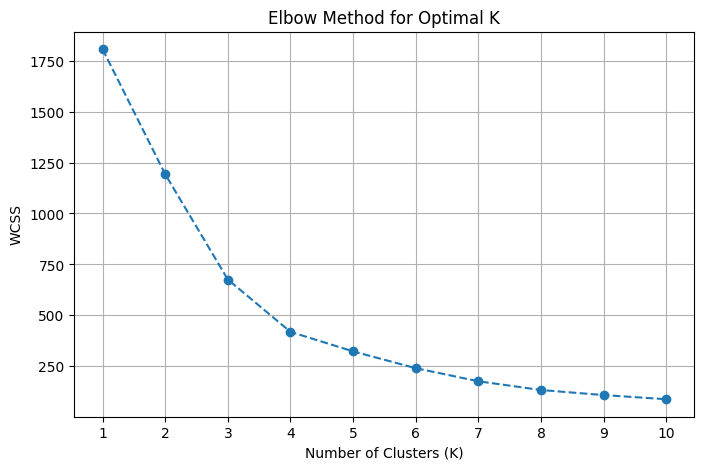

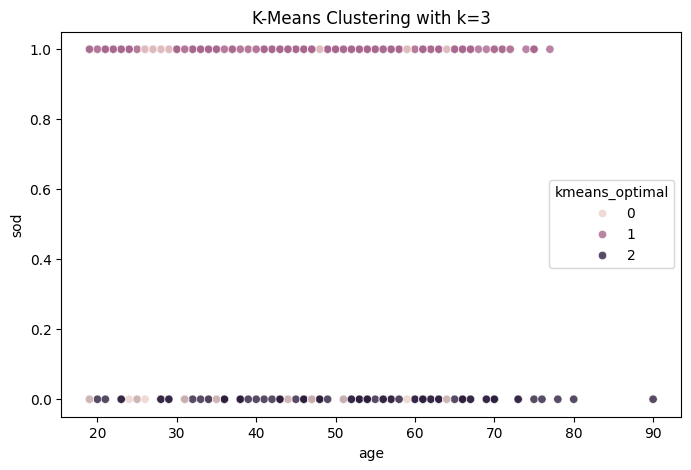

In [26]:
# First, let's try K-Means with 2 clusters
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_data['kmeans_2'] = (
    kmeans_2.fit_predict(scaled_features)
)

print("\n--- K-Means (k=2) Cluster Centers ---")
print(kmeans_2.cluster_centers_)


# Finding the suitable number of clusters
wcss = []

for i in range(1, 11):

    kmeans_temp = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans_temp.fit(scaled_features)

    wcss.append(
        kmeans_temp.inertia_
    )


# Elbow plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    linestyle='--'
)

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()


# Using 3 clusters for the final model
optimal_k = 3

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_data['kmeans_optimal'] = (
    kmeans_final.fit_predict(
        scaled_features
    )
)


# Visualizing the clusters
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=cluster_data,
    x='age',
    y='sod',
    hue='kmeans_optimal',
    alpha=0.8
)

plt.title(
    f'K-Means Clustering with k={optimal_k}'
)

plt.show()

15. Hierarchical Clustering

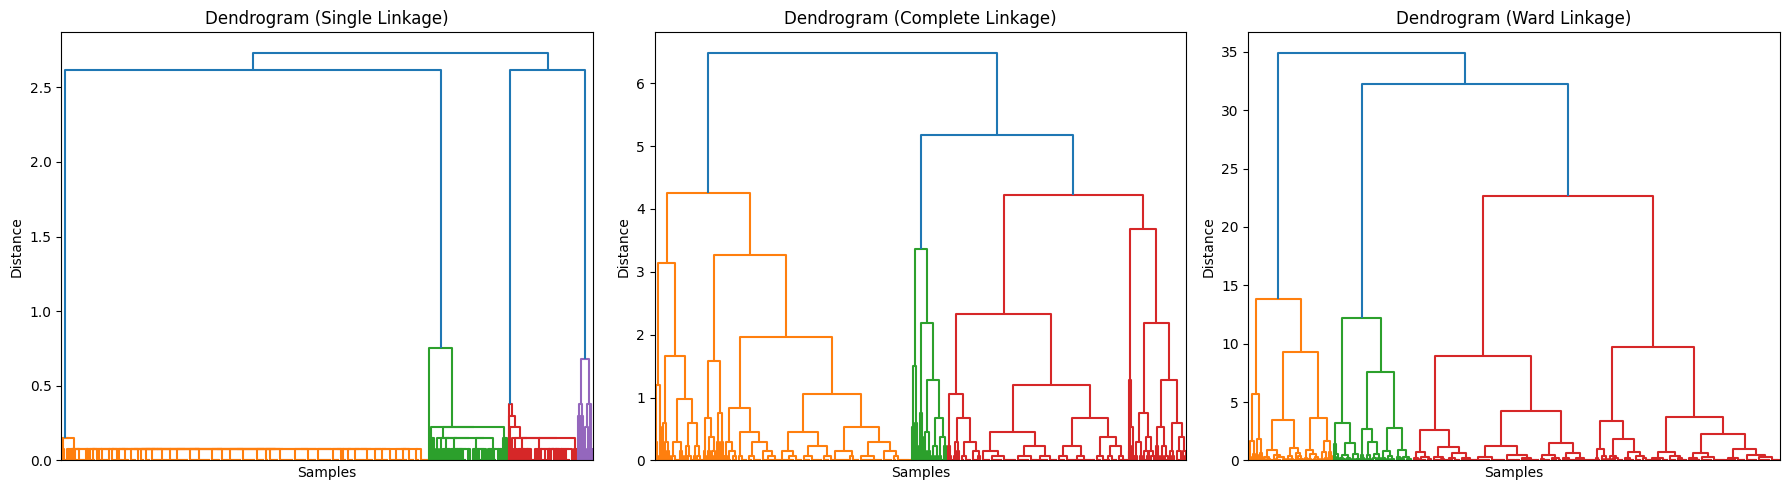


--- Hierarchical Clustering Assignment Counts ---
hierarchical_3
0    416
1     96
2     90
Name: count, dtype: int64


In [27]:
# Taking the numerical columns needed for clustering
cluster_data = data[
    ['age', 'sod', 'pep']
].dropna()


# Standardizing the values before clustering
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_data
)

# Creating dendrograms using different linkage methods

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

linkages = [
    'single',
    'complete',
    'ward'
]

for i, method in enumerate(linkages):

    sch.dendrogram(
        sch.linkage(
            scaled_features,
            method=method
        ),
        ax=axes[i],
        no_labels=True
    )

    axes[i].set_title(
        f'Dendrogram ({method.capitalize()} Linkage)'
    )

    axes[i].set_xlabel('Samples')
    axes[i].set_ylabel('Distance')


plt.tight_layout()
plt.show()


# Applying Agglomerative Clustering
hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

cluster_data['hierarchical_3'] = (
    hc.fit_predict(scaled_features)
)


# Showing how many samples are in each cluster
print(
    "\n--- Hierarchical Clustering Assignment Counts ---"
)

print(
    cluster_data[
        'hierarchical_3'
    ].value_counts().sort_index()
)